# Image encoder — Sérsic linear probes

Frozen `jwst_dino` teacher on COSMOS-Web F150W cutouts, ridge probes for Sérsic
index, effective radius and axis ratio. Writes `sersic.png`.

In [1]:
import sys, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm.auto import tqdm
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
warnings.simplefilter("ignore")

from plotstyle import (IMAGE_DIR, IMAGE_ROOT, COSMOS_PHOTOM, IMG_CKPT,
                       C_IMAGE, C_KNN, C_THIRD, use_style, style_axes, fs, save)
sys.path.insert(0, str(IMAGE_DIR))
from model.jwst_dino import load_teacher_backbone
from data.augmentations import AsinhStretch

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Sample definition is purely observational: resolved, detected, and with a fit
# that did not run into a bound. Label uncertainty is not used to select sources
# (it tracks S/N with correlation 0.9 and additionally biases against flat
# sources, because a fixed relative error is harder to reach at small axis ratio).
PSF_FWHM_PX = 0.049 / 0.030   # F150W FWHM at 30 mas/pix
MIN_REFF_PX = 1 * PSF_FWHM_PX  # resolved: Re > 1 PSF FWHM
MIN_SNR = 30.0                 # F150W detection significance
MIN_SNR_LOW = 20.0             # looser cut, quoted as the label-noise check
MAX_SAMPLES = 30000
TEST_FRAC, SEED = 0.5, 42
N_SEEDS = 40                   # resampling draws for the quoted spread
ALPHAS = np.logspace(-8, 6, 43)


def alpha_edge(a, grid=ALPHAS):
    """Flag a penalty that sits on an end of the search grid."""
    return ("FLOOR" if a <= grid[0] * 1.001 else
            "CEIL" if a >= grid[-1] * 0.999 else "ok")

# (photometry column, axis label, fit in log10?)
TARGETS = [("sersic",         r"$\log_{10} n$",         True),
           ("radius_sersic",  r"$\log_{10}\,R_e$ [px]", True),
           ("axratio_sersic", r"axis ratio $q$",         False)]
# A value pinned at a fitter bound is a failed fit, not a measurement.
RAIL_BOUNDS = {"sersic": (0.31, 8.30), "axratio_sersic": (0.05, 0.95)}

use_style(1.75)
net = load_teacher_backbone(str(IMG_CKPT), DEVICE)
CROP = net.crop_size
print(f"device {DEVICE}  crop {CROP}px")

device cuda  crop 72px


## Sample

COSMOS-Web cutouts with the catalogue's single-Sérsic fits, cut on
resolvedness, F150W detection significance and fitter rails.


In [2]:
DEG_TO_PIX = 3600 * 1000 / 30.0   # radius_sersic [deg] -> px at 30 mas/pix


class CosmosSersicDataset(Dataset):
    """COSMOS F150W cutouts with single-Sérsic labels, stacked (N, 3).

    The image index `id` is the photometry row index, so labels are read by
    direct indexing. A source is kept when it is resolved, detected above
    min_snr, and none of its parameters sits on a fitter bound.
    """

    def __init__(self, root, photom, targets, rail_bounds, filt="f150w", crop_size=72,
                 min_reff_px=3.27, min_snr=30.0, max_samples=-1, Q=20.0, scale=1.0,
                 seed=42):
        self.root = root
        self.center_crop = transforms.CenterCrop(crop_size)
        self.stretch = AsinhStretch(scale=scale, Q=Q, return_channel_pos=0)
        self.shards = {}

        index = Table.read(root / f"image_index_cosmos_{filt}.fits")
        ids = np.asarray(index["id"], np.int64)
        rel_path = np.asarray(index["rel_path"]).astype(str)
        local_idx = np.asarray(index["local_idx"], np.int64)

        ph = fits.open(photom, memmap=True)[1].data
        get = lambda c: np.asarray(ph[c], np.float64)[ids]
        val = {"sersic": get("sersic"),
               "radius_sersic": get("radius_sersic") * DEG_TO_PIX,
               "axratio_sersic": get("axratio_sersic")}
        err = {"sersic": get("sersic_err"),
               "radius_sersic": get("radius_sersic_err") * DEG_TO_PIX,
               "axratio_sersic": get("axratio_sersic_err")}
        snr = np.asarray(ph["snr_" + filt], np.float64)[ids]

        resolved = (np.isfinite(val["radius_sersic"]) & (val["radius_sersic"] >= min_reff_px)
                    & np.isfinite(val["sersic"]) & np.isfinite(val["axratio_sersic"])
                    & (val["axratio_sersic"] > 0))
        railed = np.zeros(len(ids), bool)
        for c, (lo, hi) in rail_bounds.items():
            railed |= (val[c] <= lo) | (val[c] >= hi)
        detected = np.isfinite(snr) & (snr > min_snr)

        clean = resolved & ~railed & detected
        keep = np.where(clean)[0]
        if 0 < max_samples < len(keep):
            keep = np.random.default_rng(seed).choice(keep, max_samples, replace=False)

        labels = np.stack([np.log10(val[c]) if log else val[c]
                           for c, _, log in targets], 1).astype(np.float32)
        self._samples = [(rel_path[i], local_idx[i]) for i in keep]
        self._labels = labels[keep]
        # Kept so a stricter cut can be applied to the embeddings afterwards
        # instead of re-running the encoder for every threshold.
        self.snr = snr[keep]
        self.table_idx = keep
        print(f"{len(ids)} cutouts -> {resolved.sum()} resolved (Re > {min_reff_px:.2f} px) "
              f"-> {clean.sum()} with S/N > {min_snr:g} and no railed parameter "
              f"-> {len(keep)} used")

    def _shard(self, rp):
        if rp not in self.shards:
            self.shards[rp] = np.load(self.root / rp, mmap_mode="r")
        return self.shards[rp]

    def __len__(self):
        return len(self._samples)

    def __getitem__(self, i):
        rp, li = self._samples[i]
        img = np.nan_to_num(self._shard(rp)[li].astype(np.float32))[None]
        img = self.center_crop(torch.from_numpy(img)).numpy()
        return torch.from_numpy(self.stretch(img)), self._labels[i]


# Built at the looser threshold and without subsampling: the S/N > 30 sample is a
# subset of this one, so a single pass through the encoder serves both cuts.
ds = CosmosSersicDataset(IMAGE_ROOT, COSMOS_PHOTOM, TARGETS, RAIL_BOUNDS,
                         crop_size=CROP, min_reff_px=MIN_REFF_PX, min_snr=MIN_SNR_LOW,
                         max_samples=-1, seed=SEED)
loader = DataLoader(ds, batch_size=128, shuffle=False, num_workers=8, pin_memory=True)

749154 cutouts -> 650822 resolved (Re > 1.63 px) -> 184884 with S/N > 20 and no railed parameter -> 184884 used


## Embeddings and probe

Readout is `concat(CLS, mean patch token)`; one closed-form ridge head per target.

In [3]:
@torch.no_grad()
def extract(net, loader, device):
    embs, labels = [], []
    for imgs, ys in tqdm(loader, desc="embeddings"):
        with torch.autocast(device_type=device.type, dtype=torch.bfloat16,
                            enabled=device.type == "cuda"):
            out = net(imgs.to(device))
        embs.append(torch.cat([out["cls"], out["patch"].mean(1)], 1).float().cpu().numpy())
        labels.append(np.asarray(ys))
    return np.concatenate(embs), np.concatenate(labels)


X, Y = extract(net, loader, DEVICE)

# Positions of the S/N > 30 sources within the extracted set. Drawing on their
# catalog row indices reproduces the subsample the figure has always used.
POS30 = np.where(ds.snr > MIN_SNR)[0]
_draw = np.random.default_rng(SEED).choice(ds.table_idx[POS30], MAX_SAMPLES,
                                           replace=False)
sel30 = POS30[np.isin(ds.table_idx[POS30], _draw)]
print(f"{len(ds)} sources at S/N > {MIN_SNR_LOW:g}, {len(POS30)} at S/N > {MIN_SNR:g}, "
      f"{len(sel30)} drawn\n")

Xtr, Xte, Ytr, Yte = train_test_split(X[sel30], Y[sel30], test_size=TEST_FRAC,
                                      random_state=SEED)
sc = StandardScaler().fit(Xtr)
Ztr, Zte = sc.transform(Xtr), sc.transform(Xte)

preds = np.zeros_like(Yte)
print(f"{len(Xtr)} train / {len(Xte)} test, embedding {X.shape[1]}d\n")
print(f"{'target':16s} {'R2':>7s} {'sigma_NMAD':>11s} {'alpha':>10s}")
for j, (col, _, _) in enumerate(TARGETS):
    r = RidgeCV(alphas=ALPHAS).fit(Ztr, Ytr[:, j])
    preds[:, j] = r.predict(Zte)
    d = preds[:, j] - Yte[:, j]
    print(f"{col:16s} {r2_score(Yte[:, j], preds[:, j]):7.3f} "
          f"{1.4826 * np.median(np.abs(d - np.median(d))):11.4f} "
          f"{r.alpha_:10.2e} {alpha_edge(r.alpha_)}")

embeddings:   0%|          | 0/1445 [00:00<?, ?it/s]

184884 sources at S/N > 20, 134607 at S/N > 30, 30000 drawn

15000 train / 15000 test, embedding 1024d

target                R2  sigma_NMAD      alpha


sersic             0.638      0.1039   2.15e+02 ok


radius_sersic      0.808      0.0693   2.15e+02 ok


axratio_sersic     0.778      0.0737   4.64e+01 ok


## Zero-shot k-NN

Non-parametric readout on the same embeddings and the same split, quoted in the
text alongside the linear probe.

In [4]:
# k=5 neighbour average on the standardized embeddings; distances on the GPU in
# chunks, since a 15k x 15k dense distance matrix is the whole cost here.
KNN_K, CHUNK = 5, 2048


@torch.no_grad()
def knn_predict(Ztr, Zte, Ytr, k=KNN_K):
    A = torch.as_tensor(Ztr, dtype=torch.float32, device=DEVICE)
    B = torch.as_tensor(Zte, dtype=torch.float32, device=DEVICE)
    L = torch.as_tensor(Ytr, dtype=torch.float32, device=DEVICE)
    a2 = (A * A).sum(1)                      # ||a||^2; the ||b||^2 term is constant per row
    out = []
    for s in range(0, B.shape[0], CHUNK):
        b = B[s:s + CHUNK]
        score = -(a2[None, :] - 2.0 * (b @ A.T))
        out.append(L[score.topk(k, dim=1).indices].mean(1).cpu().numpy())
    return np.concatenate(out)


knn_pred = knn_predict(Ztr, Zte, Ytr)
print(f"{'target':16s} {'R2 knn':>8s} {'R2 ridge':>9s}")
for j, (col, _, _) in enumerate(TARGETS):
    print(f"{col:16s} {r2_score(Yte[:, j], knn_pred[:, j]):8.3f} "
          f"{r2_score(Yte[:, j], preds[:, j]):9.3f}")
print(f"\nmean R2   zero-shot {np.mean([r2_score(Yte[:, j], knn_pred[:, j]) for j in range(3)]):.3f}"
      f"   linear {np.mean([r2_score(Yte[:, j], preds[:, j]) for j in range(3)]):.3f}")

target             R2 knn  R2 ridge
sersic              0.506     0.638
radius_sersic       0.748     0.808
axratio_sersic      0.554     0.778

mean R2   zero-shot 0.603   linear 0.741


## Figure

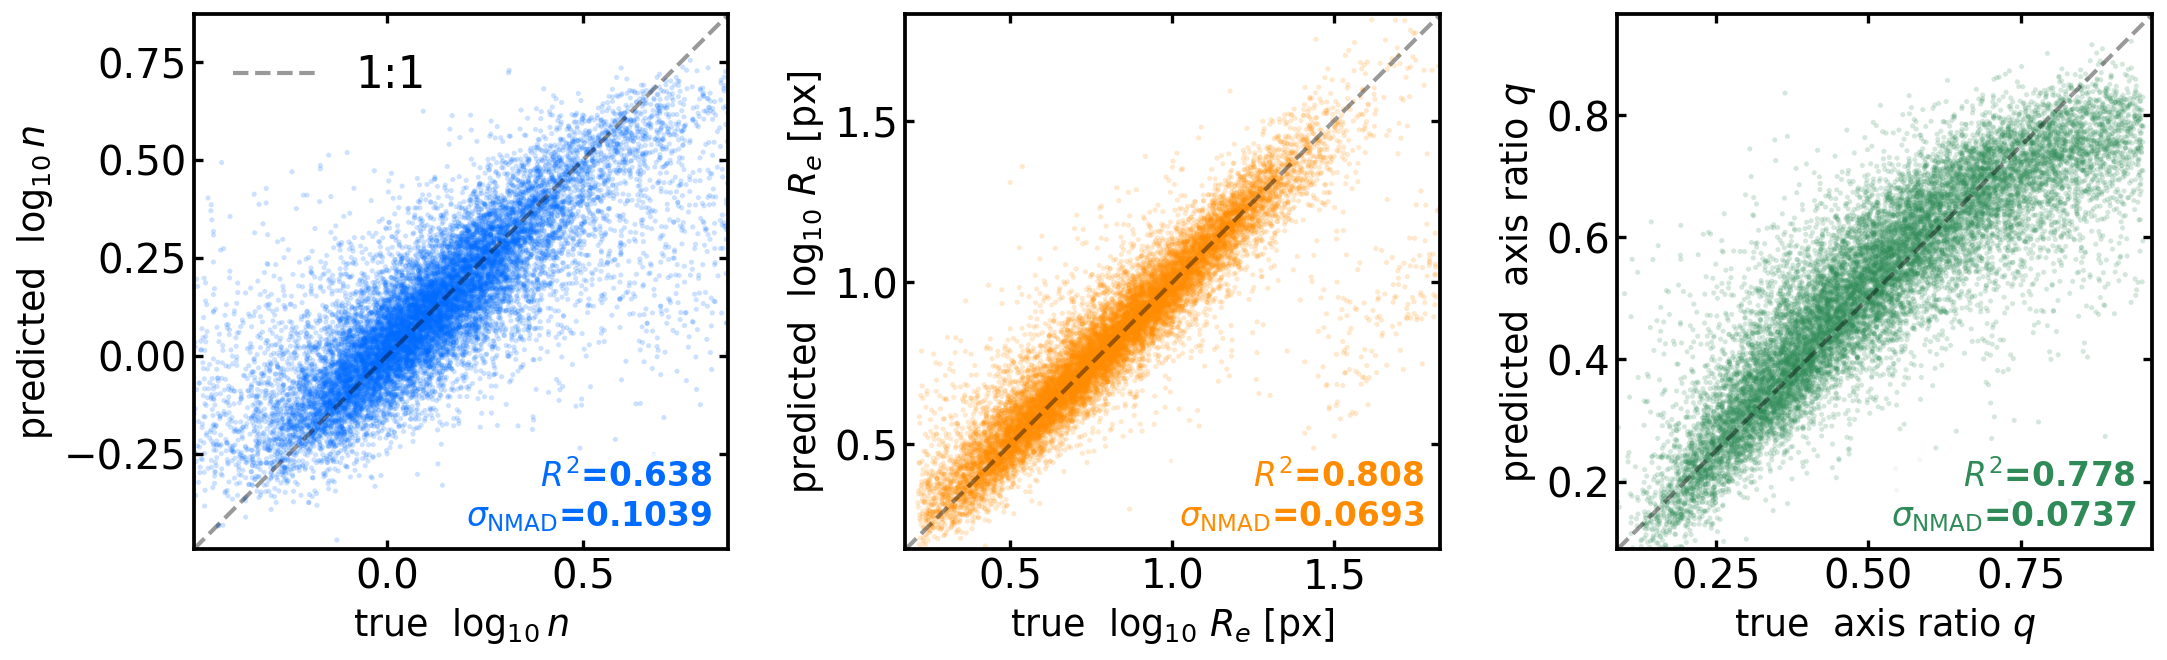

In [5]:
def sigma_nmad(t, p):
    d = p - t
    return 1.4826 * np.median(np.abs(d - np.median(d)))


PANEL_C = [C_IMAGE, C_KNN, C_THIRD]
PAD = 0.05   # axis margin as a fraction of the plotted range

fig, axes = plt.subplots(1, len(TARGETS), figsize=(5 * len(TARGETS), 4.8))
for j, (ax, (col, label, _)) in enumerate(zip(axes, TARGETS)):
    t, p, c = Yte[:, j], preds[:, j], PANEL_C[j % len(PANEL_C)]
    lo, hi = np.percentile(np.concatenate([t, p]), [0.5, 99.5])
    m = PAD * (hi - lo)
    lo, hi = lo - m, hi + m

    ax.scatter(t, p, s=6, alpha=0.2, edgecolors="none", color=c)
    ax.plot([lo, hi], [lo, hi], "--", lw=2, color="black", alpha=0.4, label="1:1")
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_box_aspect(1)
    ax.set_xlabel(rf"true  {label}", fontsize=fs(10))
    ax.set_ylabel(rf"predicted  {label}", fontsize=fs(10))
    ax.text(0.97, 0.03, rf"$R^2$={r2_score(t, p):.3f}" + "\n"
            + rf"$\sigma_{{\rm NMAD}}$={sigma_nmad(t, p):.4f}",
            transform=ax.transAxes, ha="right", va="bottom", fontsize=fs(9), color=c,
            fontweight="bold",
            bbox=dict(facecolor="white", alpha=0.7, pad=3.0, edgecolor="none"))
    if j == 0:
        ax.legend(fontsize=fs(12), loc="upper left", frameon=False)
    style_axes(ax)

fig.patch.set_alpha(0.0)
fig.tight_layout()
save(fig, "sersic")
plt.show()

## Resampling spread and the looser detection cut

In [6]:
# === how much of the probe score is the particular draw, and what the looser cut costs ===
# The encoder is not re-run: both cuts index the embeddings already extracted. The
# penalty is chosen once per target on the first draw and then held fixed, so the
# spread reported here is the spread of the sample, not of the penalty search.
from sklearn.linear_model import Ridge

CUTS = [("S/N > 30", np.where(ds.snr > MIN_SNR)[0]),
        ("S/N > 20", np.arange(len(ds)))]

summary = {}
for name, pool in CUTS:
    r2 = np.zeros((N_SEEDS, len(TARGETS)))
    nm = np.zeros((N_SEEDS, len(TARGETS)))
    alphas = None
    for s in range(N_SEEDS):
        draw = np.random.default_rng(s).choice(pool, min(MAX_SAMPLES, len(pool)),
                                               replace=False)
        xtr, xte, ytr, yte = train_test_split(X[draw], Y[draw], test_size=TEST_FRAC,
                                              random_state=s)
        scl = StandardScaler().fit(xtr)
        ztr, zte = scl.transform(xtr), scl.transform(xte)
        if alphas is None:
            alphas = [RidgeCV(alphas=ALPHAS).fit(ztr, ytr[:, j]).alpha_
                      for j in range(len(TARGETS))]
        for j in range(len(TARGETS)):
            p = Ridge(alpha=alphas[j]).fit(ztr, ytr[:, j]).predict(zte)
            r2[s, j] = r2_score(yte[:, j], p)
            nm[s, j] = sigma_nmad(yte[:, j], p)
    summary[name] = (r2, nm, len(pool))

    print(f"=== {name}: {len(pool)} sources, {N_SEEDS} draws of "
          f"{min(MAX_SAMPLES, len(pool))} ===")
    print(f"{'target':16s} {'R2':>16s} {'sigma_NMAD':>18s} {'alpha':>10s}")
    for j, (col, _, _) in enumerate(TARGETS):
        print(f"{col:16s} {r2[:, j].mean():7.3f}+/-{r2[:, j].std():<7.3f} "
              f"{nm[:, j].mean():8.4f}+/-{nm[:, j].std():<8.4f} {alphas[j]:10.2e}")
    print()

r2_rms = max(summary[n][0].std(0).max() for n, _ in CUTS)
nm_rms = max(summary[n][1].std(0).max() for n, _ in CUTS)
print(f"caption: random resampling changes the metrics by {r2_rms:.3f} in R2 "
      f"and {nm_rms:.3f} in sigma_NMAD (rms over {N_SEEDS} draws)")


=== S/N > 30: 134607 sources, 40 draws of 30000 ===
target                         R2         sigma_NMAD      alpha
sersic             0.646+/-0.005     0.1042+/-0.0009     2.15e+02
radius_sersic      0.812+/-0.006     0.0693+/-0.0007     2.15e+02
axratio_sersic     0.785+/-0.004     0.0740+/-0.0006     4.64e+01



=== S/N > 20: 184884 sources, 40 draws of 30000 ===
target                         R2         sigma_NMAD      alpha
sersic             0.570+/-0.008     0.1188+/-0.0014     4.64e+02
radius_sersic      0.775+/-0.006     0.0762+/-0.0011     2.15e+02
axratio_sersic     0.736+/-0.003     0.0811+/-0.0008     1.00e+02

caption: random resampling changes the metrics by 0.008 in R2 and 0.001 in sigma_NMAD (rms over 40 draws)
